=== ZND reference for modern 2D Step 6 ===
D_CJ                       = 6.415008470922
reaction length (10%-90%) = 40.70515646
reaction length (5%-95%)  = 55.90595739
s(lambda=0.5)             = 13.84532009
s(lambda=0.9)             = 43.20641311
q_end/c_end               = 0.999996709958

=== Modern Step 6: stronger perturbed 2D CJ-ZND test with cellular diagnostics ===
Domain s                   = [-20.000, 150.000]
Domain y                   = [0.000, 30.000]
Nx, Ny                     = 900, 64
dx, dy                     = 1.88888889e-01, 4.68750000e-01
final_time                 = 12.00000000
CFL                        = 0.16000000
react_cfl                  = 0.20000000
time steps                 = 3786
reaction substeps          = 7572
D_ref                      = 6.415008470922
solver                     = HLLC+MUSCL
step6_case                 = strong

Perturbation parameters:
                   shock_amp = 1.6
                        mode = 1
                       phase = 0.

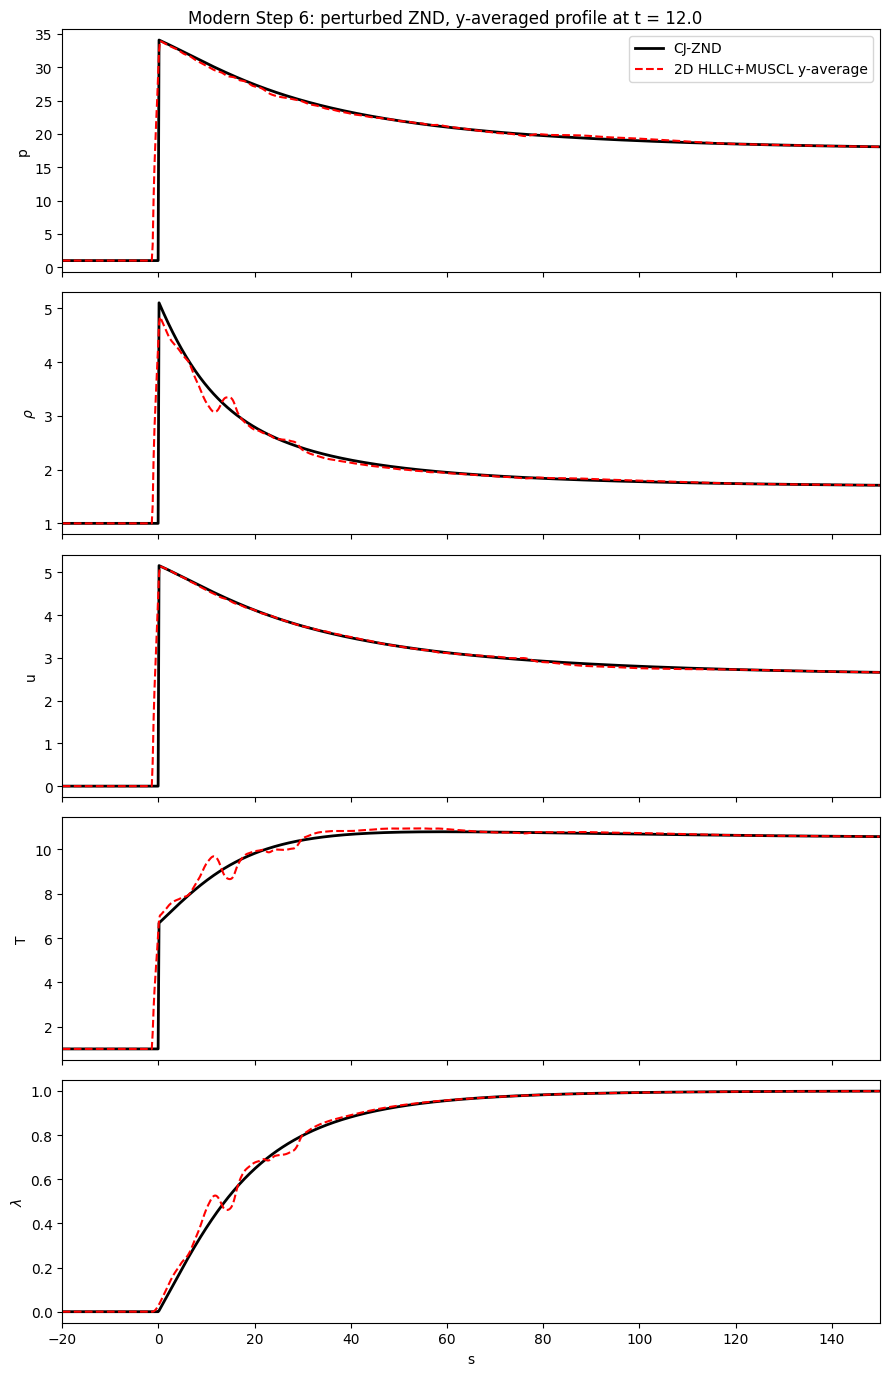

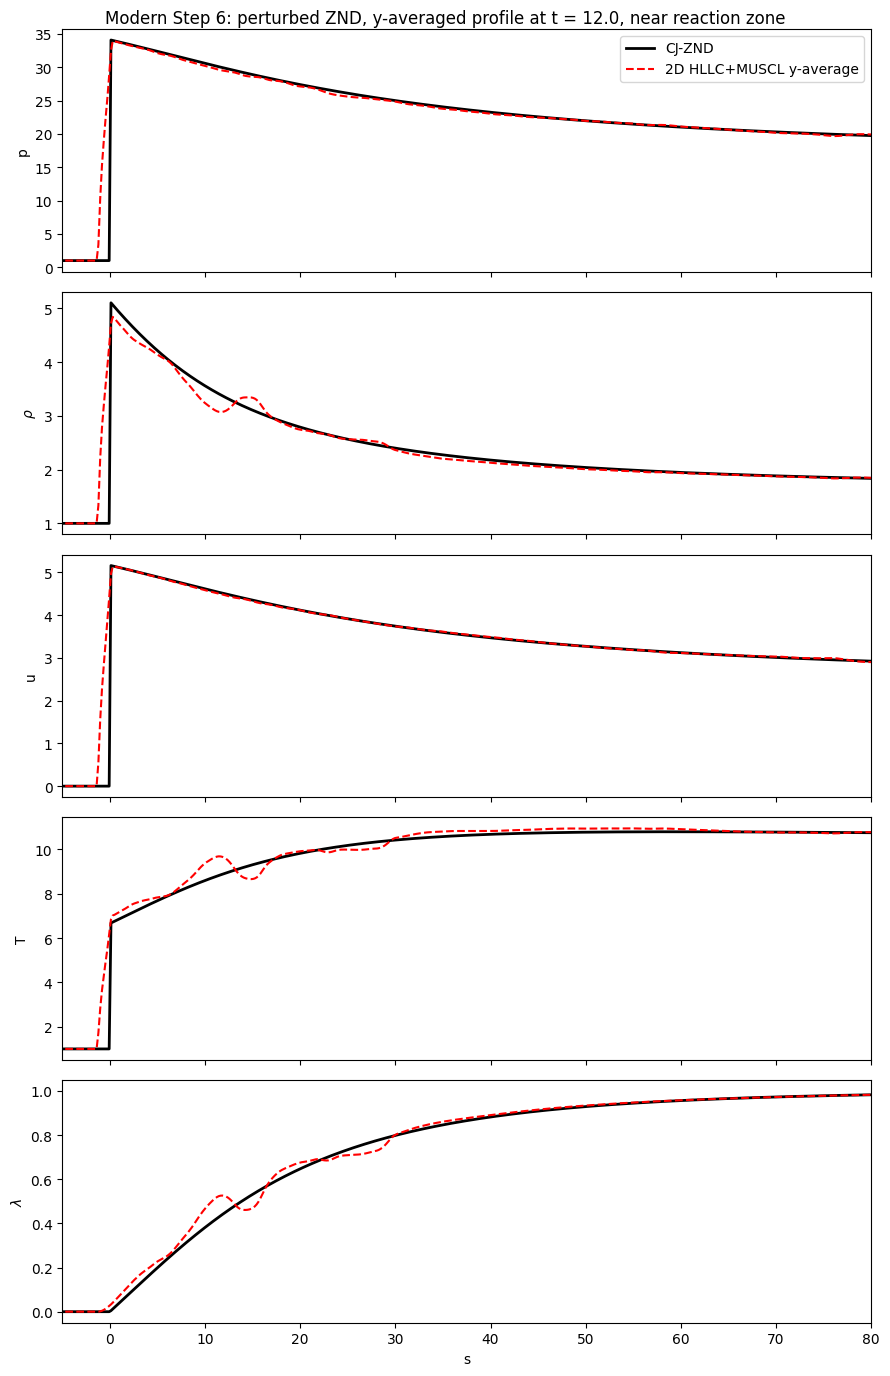

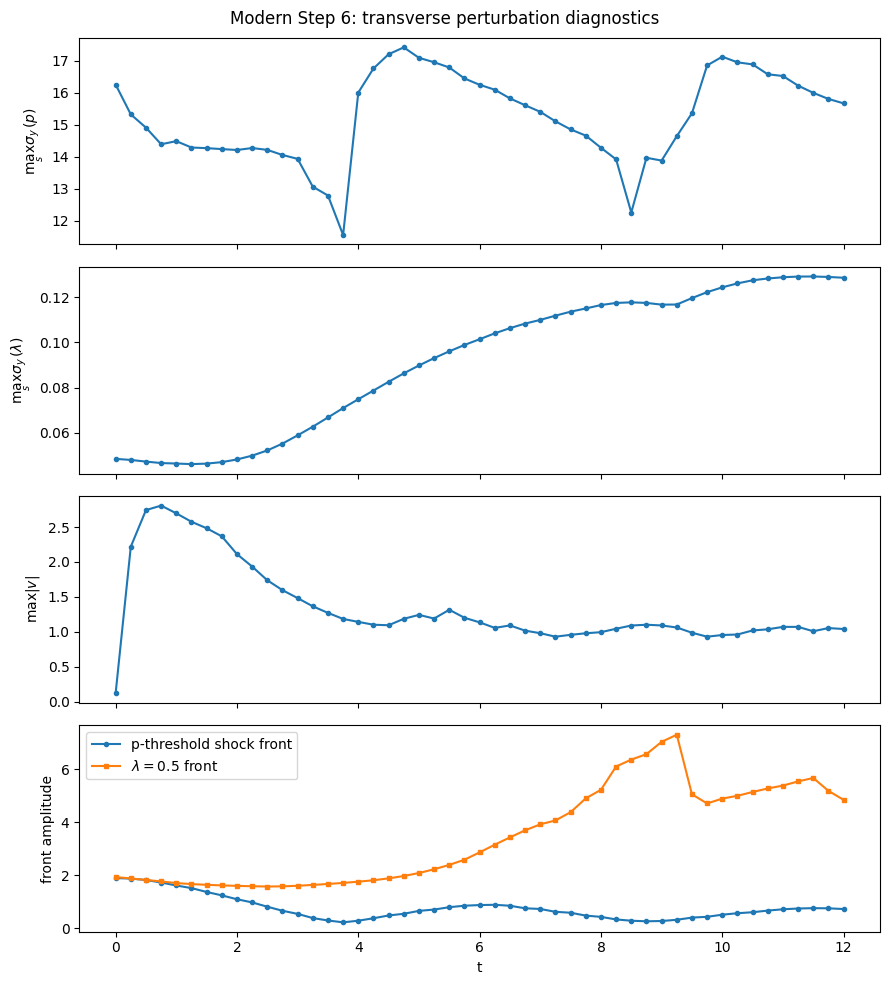

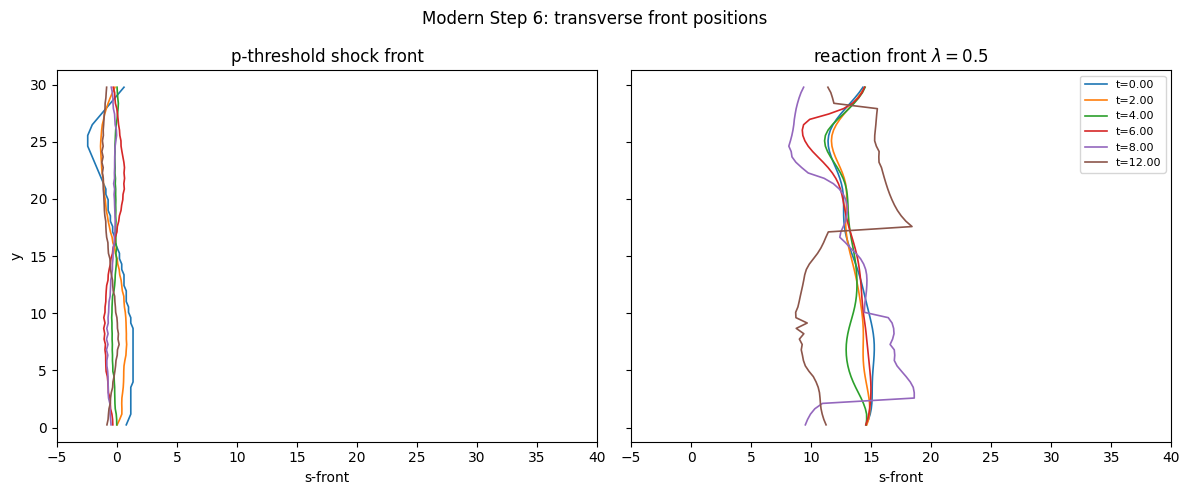

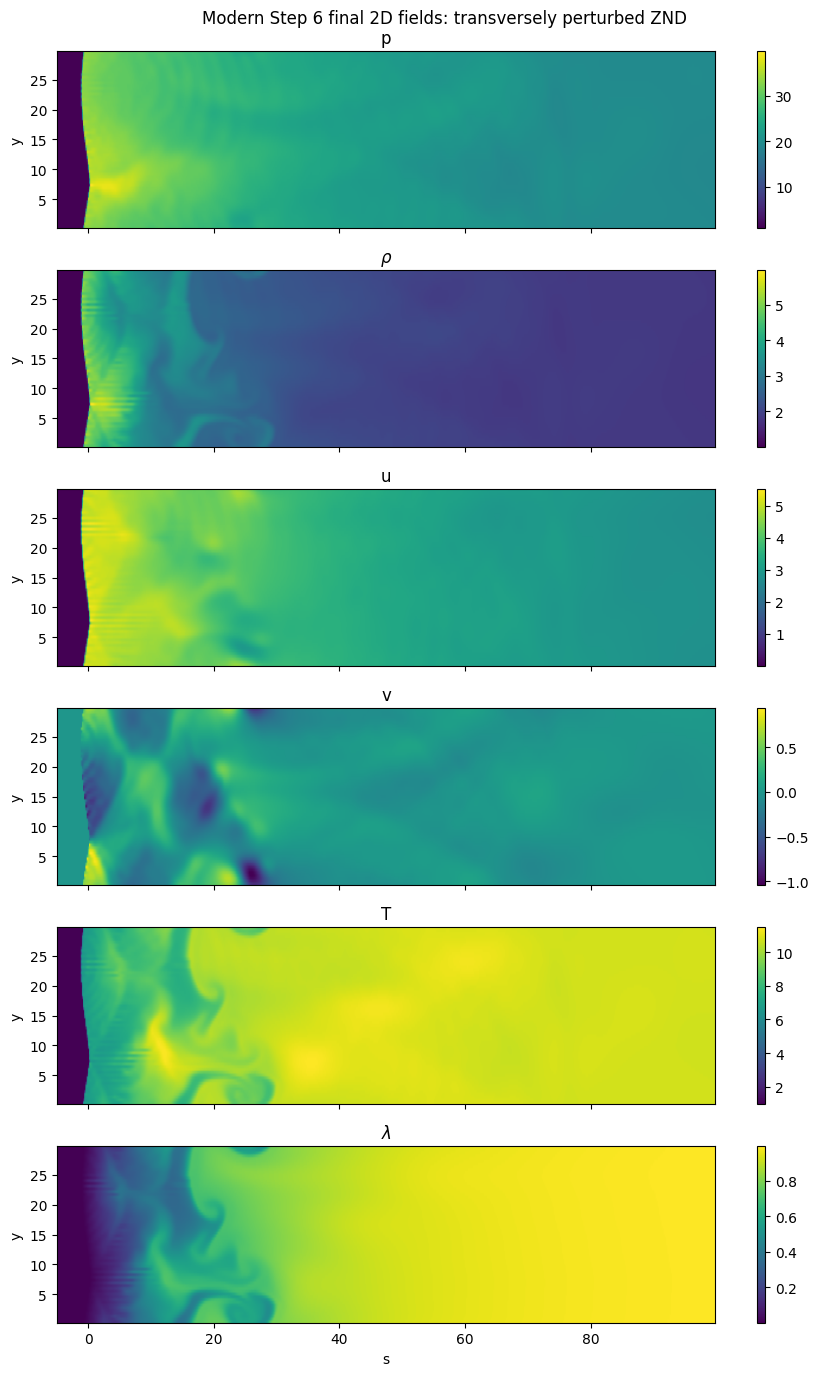

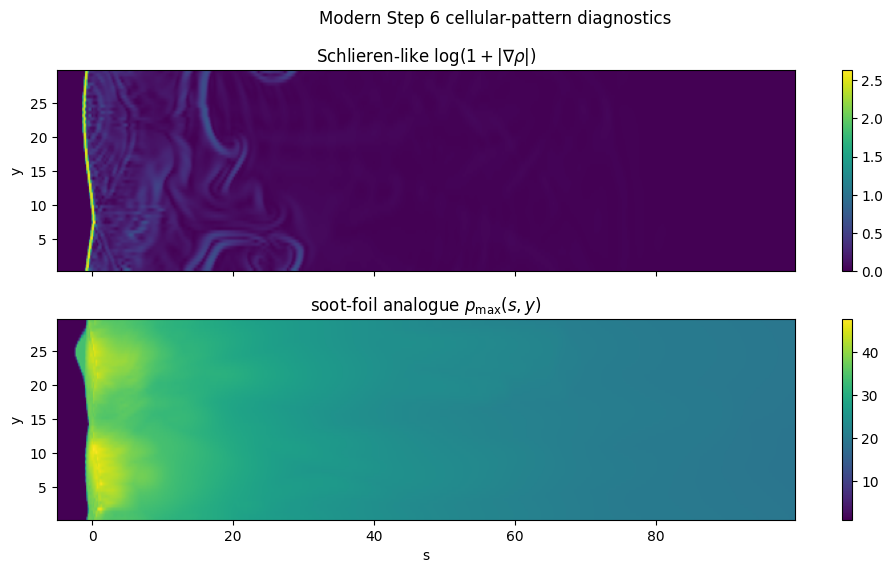

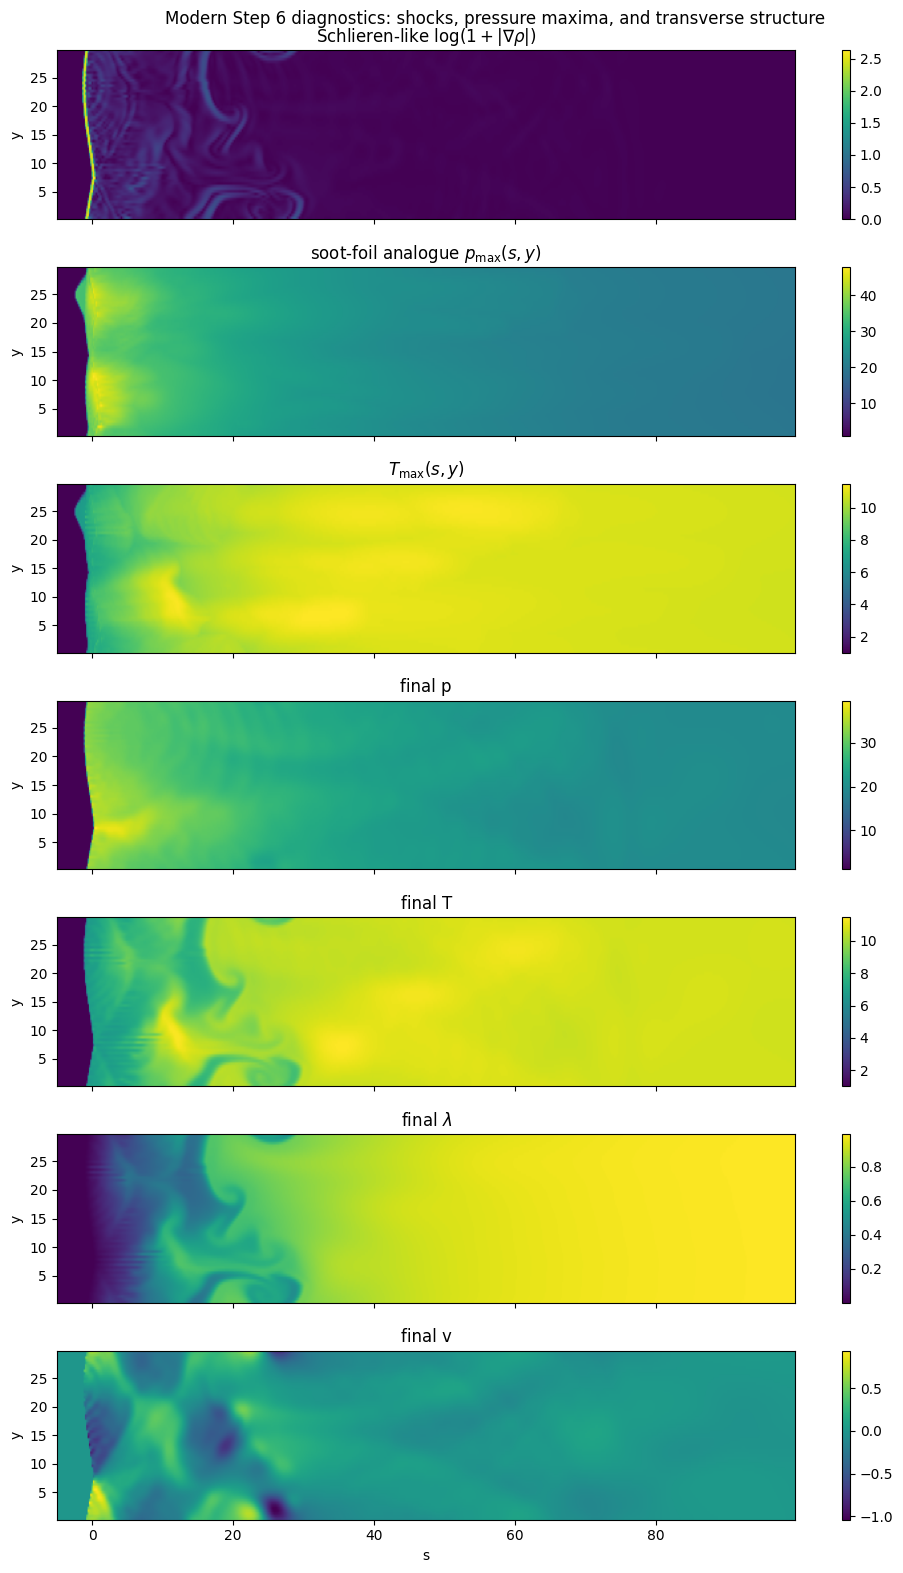

In [ ]:
# MODERN 2D : HLLC+MUSCL nonlinear transverse perturbations and cellular diagnostics
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import math





# ZND reference solver


class ZNDFailure(Exception):
    def __init__(self, lam_fail, last_state=None, message="ZND profile terminated before lam_end"):
        super().__init__(message)
        self.lam_fail = lam_fail
        self.last_state = last_state


@dataclass
class Params:
    gamma: float = 1.4
    Q: float = 20.0
    k: float = 1.0
    Ea: float = 20.0
    R: float = 1.0

    rho_a: float = 1.0
    u_a: float = 0.0
    p_a: float = 1.0
    lam_a: float = 0.0

    n_lam: int = 4000
    lam_end: float = 1.0 - 1.0e-6

    D_bracket_low: float = 1.3
    D_bracket_high: float = 7.0
    cj_tol: float = 1.0e-10
    cj_max_iter: int = 80


def reaction_rate_znd(lam, T, p: Params):
    return p.k * (1.0 - lam) * np.exp(-p.Ea / (p.R * T))


def shock_jump(par: Params, D):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    q_a = D - par.u_a
    if q_a <= c_a:
        raise ValueError("D is too small: upstream state is not supersonic relative to the shock.")

    M_a = q_a / c_a

    rho_n = par.rho_a * ((par.gamma + 1.0) * M_a**2) / ((par.gamma - 1.0) * M_a**2 + 2.0)
    p_n = par.p_a * (1.0 + 2.0 * par.gamma / (par.gamma + 1.0) * (M_a**2 - 1.0))
    q_n = q_a * par.rho_a / rho_n
    u_n = D - q_n
    lam_n = par.lam_a

    m = rho_n * q_n
    P = p_n + rho_n * q_n**2
    B = par.gamma / (par.gamma - 1.0) * (p_n / rho_n) - par.Q * lam_n + 0.5 * q_n**2

    T_n = p_n / (rho_n * par.R)
    c_n = math.sqrt(par.gamma * p_n / rho_n)

    vn = {
        "rho": rho_n,
        "u": u_n,
        "q": q_n,
        "p": p_n,
        "T": T_n,
        "c": c_n,
        "lam": lam_n,
    }
    inv = {"m": m, "P": P, "B": B}
    return vn, inv


def state_from_lambda(lam, inv, par: Params, D, v_prev):
    m = inv["m"]
    P = inv["P"]
    B = inv["B"]

    a = m**2 * (par.gamma + 1.0) / (2.0 * (par.gamma - 1.0))
    b = -par.gamma * P / (par.gamma - 1.0)
    c = B + par.Q * lam

    disc = b**2 - 4.0 * a * c
    if disc < 0.0:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    sqrt_disc = math.sqrt(disc)
    roots = [(-b - sqrt_disc) / (2.0 * a), (-b + sqrt_disc) / (2.0 * a)]

    candidates = []
    for v in roots:
        if v <= 0.0:
            continue
        rho = 1.0 / v
        q = m * v
        p = P - m**2 * v
        if rho > 0.0 and q > 0.0 and p > 0.0:
            candidates.append(v)

    if not candidates:
        raise ZNDFailure(lam_fail=lam, last_state=None)

    v = min(candidates, key=lambda x: abs(x - v_prev))

    rho = 1.0 / v
    q = m * v
    u = D - q
    p = P - m**2 * v
    T = p / (rho * par.R)
    c = math.sqrt(par.gamma * p / rho)
    M_rel = q / c
    omega = reaction_rate_znd(lam, T, par)

    return {
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "v": v,
    }


def build_znd_profile(par: Params, D):
    vn, inv = shock_jump(par, D)

    lam = np.linspace(par.lam_a, par.lam_end, par.n_lam)

    rho = np.empty_like(lam)
    u = np.empty_like(lam)
    q = np.empty_like(lam)
    p = np.empty_like(lam)
    T = np.empty_like(lam)
    c = np.empty_like(lam)
    M_rel = np.empty_like(lam)
    omega = np.empty_like(lam)
    s = np.empty_like(lam)

    v_prev = 1.0 / vn["rho"]
    last_state = None

    for i, lam_i in enumerate(lam):
        try:
            st = state_from_lambda(lam_i, inv, par, D, v_prev)
        except ZNDFailure:
            raise ZNDFailure(lam_fail=lam_i, last_state=last_state)

        v_prev = st["v"]
        last_state = st

        rho[i] = st["rho"]
        u[i] = st["u"]
        q[i] = st["q"]
        p[i] = st["p"]
        T[i] = st["T"]
        c[i] = st["c"]
        M_rel[i] = st["M_rel"]
        omega[i] = st["omega"]

    ds_dlam = q / omega
    s[0] = 0.0
    for i in range(1, len(lam)):
        dlam = lam[i] - lam[i - 1]
        s[i] = s[i - 1] + 0.5 * (ds_dlam[i] + ds_dlam[i - 1]) * dlam

    m_prof = rho * q
    P_prof = p + rho * q**2
    B_prof = par.gamma / (par.gamma - 1.0) * (p / rho) - par.Q * lam + 0.5 * q**2

    s_lam_05 = np.interp(0.5, lam, s)
    s_lam_09 = np.interp(0.9, lam, s)
    s_lam_095 = np.interp(0.95, lam, s)
    s_lam_005 = np.interp(0.05, lam, s)

    out = {
        "D": D,
        "s": s,
        "lam": lam,
        "rho": rho,
        "u": u,
        "q": q,
        "p": p,
        "T": T,
        "c": c,
        "M_rel": M_rel,
        "omega": omega,
        "vn_state": vn,
        "invariants": inv,
        "m_prof": m_prof,
        "P_prof": P_prof,
        "B_prof": B_prof,
        "reaction_length_10_90": np.interp(0.9, lam, s) - np.interp(0.1, lam, s),
        "reaction_length_5_95": s_lam_095 - s_lam_005,
        "reaction_length_total": s[-1],
        "s_lam_05": s_lam_05,
        "s_lam_09": s_lam_09,
        "p_max": np.max(p),
        "T_max": np.max(T),
        "q_end_over_c_end": M_rel[-1],
        "s_at_p_max": s[np.argmax(p)],
        "s_at_T_max": s[np.argmax(T)],
    }
    return out


def try_build_profile(par: Params, D):
    try:
        prof = build_znd_profile(par, D)
        return True, prof, None
    except Exception as e:
        return False, None, e


def find_cj_speed(par: Params):
    c_a = math.sqrt(par.gamma * par.p_a / par.rho_a)
    Dmin = c_a * (1.0 + 1.0e-12)

    D_low = max(par.D_bracket_low, Dmin)
    D_high = max(par.D_bracket_high, 1.1 * D_low)

    ok_low, _, _ = try_build_profile(par, D_low)
    while ok_low and D_low > Dmin * 1.000001:
        D_low = 0.5 * (D_low + Dmin)
        ok_low, _, _ = try_build_profile(par, D_low)

    if ok_low:
        raise RuntimeError("Could not find a failing lower bracket for CJ search.")

    ok_high, prof_high, _ = try_build_profile(par, D_high)
    while not ok_high:
        D_high *= 1.2
        ok_high, prof_high, _ = try_build_profile(par, D_high)

    for _ in range(par.cj_max_iter):
        D_mid = 0.5 * (D_low + D_high)
        ok_mid, prof_mid, _ = try_build_profile(par, D_mid)

        if ok_mid:
            D_high = D_mid
            prof_high = prof_mid
        else:
            D_low = D_mid

        if abs(D_high - D_low) <= par.cj_tol * max(1.0, abs(D_high)):
            break

    return {
        "D_cj": D_high,
        "D_fail": D_low,
        "D_succeed": D_high,
        "profile": prof_high,
    }




# 2D PDE helpers: U = (rho, rho*u, rho*v, E, rho*lambda)


def prim_to_cons_2d(rho, u, v, p, lam, gamma, Q):
    rho = np.asarray(rho, dtype=float)
    u = np.asarray(u, dtype=float)
    v = np.asarray(v, dtype=float)
    p = np.asarray(p, dtype=float)
    lam = np.asarray(lam, dtype=float)
    z = rho * lam
    E = p / (gamma - 1.0) + 0.5 * rho * (u**2 + v**2) - Q * z
    U = np.empty(rho.shape + (5,), dtype=float)
    U[..., 0] = rho
    U[..., 1] = rho * u
    U[..., 2] = rho * v
    U[..., 3] = E
    U[..., 4] = z
    return U


def cons_to_prim_2d(U, gamma, Q, check=True):
    rho = U[..., 0]
    mx = U[..., 1]
    my = U[..., 2]
    E = U[..., 3]
    z = U[..., 4]

    if check and np.any(rho <= 0.0):
        raise ValueError(f"Non-positive density encountered: min(rho) = {np.min(rho):.16e}")

    u = mx / rho
    v = my / rho
    lam = z / rho
    kinetic = 0.5 * (mx**2 + my**2) / rho
    p = (gamma - 1.0) * (E - kinetic + Q * z)

    if check and np.any(p <= 0.0):
        raise ValueError(f"Non-positive pressure encountered: min(p) = {np.min(p):.16e}")

    return rho, u, v, p, lam


def temperature_from_prim_2d(rho, p, Rgas):
    return p / (rho * Rgas)


def reaction_rate_from_prim_2d(rho, p, lam, k, Ea, Rgas):
    T = np.maximum(p / (rho * Rgas), 1.0e-14)
    lam_clip = np.clip(lam, 0.0, 1.0)
    return k * (1.0 - lam_clip) * np.exp(-Ea / (Rgas * T))


def flux_x(U, gamma, Q):
    rho, u, v, p, lam = cons_to_prim_2d(U, gamma, Q)
    mx = U[..., 1]
    my = U[..., 2]
    E = U[..., 3]
    z = U[..., 4]
    F = np.empty_like(U)
    F[..., 0] = mx
    F[..., 1] = mx * u + p
    F[..., 2] = my * u
    F[..., 3] = u * (E + p)
    F[..., 4] = u * z
    return F


def flux_y(U, gamma, Q):
    rho, u, v, p, lam = cons_to_prim_2d(U, gamma, Q)
    mx = U[..., 1]
    my = U[..., 2]
    E = U[..., 3]
    z = U[..., 4]
    G = np.empty_like(U)
    G[..., 0] = my
    G[..., 1] = mx * v
    G[..., 2] = my * v + p
    G[..., 3] = v * (E + p)
    G[..., 4] = v * z
    return G



# Boundary conditions


def apply_bc_2d(U, x_bc="outflow", left_state=None, right_state=None):
    """One ghost layer. Dirichlet/outflow in s and periodic in y."""
    if x_bc == "outflow":
        U[0, :, :] = U[1, :, :]
        U[-1, :, :] = U[-2, :, :]
    elif x_bc == "dirichlet":
        if left_state is None or right_state is None:
            raise ValueError("Dirichlet x_bc requires left_state and right_state.")
        U[0, :, :] = left_state
        U[-1, :, :] = right_state
    else:
        raise ValueError(f"Unknown x_bc={x_bc}")

    U[:, 0, :] = U[:, -2, :]
    U[:, -1, :] = U[:, 1, :]

    if x_bc == "dirichlet":
        U[0, :, :] = left_state
        U[-1, :, :] = right_state
    return U



# 2D HLLC + MUSCL transport kernel


def _safe_denom(x, eps=1.0e-14):
    return np.where(np.abs(x) < eps, eps * np.where(x >= 0.0, 1.0, -1.0), x)


def primitive_stack_2d(U, gamma, Q):
    rho, u, v, p, lam = cons_to_prim_2d(U, gamma, Q)
    return np.stack((rho, u, v, p, lam), axis=-1)


def prim_stack_to_cons_2d(W, gamma, Q):
    return prim_to_cons_2d(W[..., 0], W[..., 1], W[..., 2], W[..., 3], W[..., 4], gamma, Q)


def minmod3(a, b, c):
    sgn = 0.25 * np.abs(np.sign(a) + np.sign(b)) * (np.sign(a) + np.sign(c))
    return sgn * np.minimum(np.abs(a), np.minimum(np.abs(b), np.abs(c)))


def mc_limiter(dm, dp):
    return minmod3(0.5 * (dm + dp), 2.0 * dm, 2.0 * dp)


def clip_reconstructed_primitives(W):
    Wc = W.copy()
    eps = 1.0e-12
    Wc[..., 0] = np.maximum(Wc[..., 0], eps)
    Wc[..., 3] = np.maximum(Wc[..., 3], eps)
    Wc[..., 4] = np.clip(Wc[..., 4], 0.0, 1.0)
    return Wc


def reconstruct_muscl_x(Uc, gamma, Q):
    W = primitive_stack_2d(Uc, gamma, Q)
    Nx = Uc.shape[0] - 2
    Ny = Uc.shape[1] - 2

    dm = W[1:-1, 1:-1, :] - W[:-2, 1:-1, :]
    dp = W[2:, 1:-1, :] - W[1:-1, 1:-1, :]
    slope = mc_limiter(dm, dp)

    WL = clip_reconstructed_primitives(W[1:-1, 1:-1, :] - 0.5 * slope)
    WR = clip_reconstructed_primitives(W[1:-1, 1:-1, :] + 0.5 * slope)

    UL = np.zeros((Nx + 1, Ny, 5))
    UR = np.zeros((Nx + 1, Ny, 5))

    UL[0, :, :] = Uc[0, 1:-1, :]
    UR[0, :, :] = prim_stack_to_cons_2d(WL[0, :, :], gamma, Q)
    if Nx > 1:
        UL[1:Nx, :, :] = prim_stack_to_cons_2d(WR[:-1, :, :], gamma, Q)
        UR[1:Nx, :, :] = prim_stack_to_cons_2d(WL[1:, :, :], gamma, Q)
    UL[Nx, :, :] = prim_stack_to_cons_2d(WR[-1, :, :], gamma, Q)
    UR[Nx, :, :] = Uc[-1, 1:-1, :]
    return UL, UR


def reconstruct_muscl_y(Uc, gamma, Q):
    W = primitive_stack_2d(Uc, gamma, Q)
    Nx = Uc.shape[0] - 2
    Ny = Uc.shape[1] - 2

    dm = W[1:-1, 1:-1, :] - W[1:-1, :-2, :]
    dp = W[1:-1, 2:, :] - W[1:-1, 1:-1, :]
    slope = mc_limiter(dm, dp)

    WB = clip_reconstructed_primitives(W[1:-1, 1:-1, :] - 0.5 * slope)
    WT = clip_reconstructed_primitives(W[1:-1, 1:-1, :] + 0.5 * slope)

    UB = np.zeros((Nx, Ny + 1, 5))
    UT = np.zeros((Nx, Ny + 1, 5))

    UB[:, 0, :] = Uc[1:-1, 0, :]
    UT[:, 0, :] = prim_stack_to_cons_2d(WB[:, 0, :], gamma, Q)
    if Ny > 1:
        UB[:, 1:Ny, :] = prim_stack_to_cons_2d(WT[:, :-1, :], gamma, Q)
        UT[:, 1:Ny, :] = prim_stack_to_cons_2d(WB[:, 1:, :], gamma, Q)
    UB[:, Ny, :] = prim_stack_to_cons_2d(WT[:, -1, :], gamma, Q)
    UT[:, Ny, :] = Uc[1:-1, -1, :]
    return UB, UT


def physical_flux_normal_minus_dU(U, gamma, Q, direction="x", Dref=0.0):
    if direction == "x":
        return flux_x(U, gamma, Q) - Dref * U
    if direction == "y":
        return flux_y(U, gamma, Q) - Dref * U
    raise ValueError(f"Unknown direction={direction}")


def hllc_flux_normal_minus_dU(UL, UR, gamma, Q, direction="x", Dref=0.0):

    rhoL, uL, vL, pL, lamL = cons_to_prim_2d(UL, gamma, Q)
    rhoR, uR, vR, pR, lamR = cons_to_prim_2d(UR, gamma, Q)

    if direction == "x":
        unL, unR = uL, uR
        utL, utR = vL, vR
    elif direction == "y":
        unL, unR = vL, vR
        utL, utR = uL, uR
    else:
        raise ValueError(f"Unknown direction={direction}")

    EL = UL[..., 3]
    ER = UR[..., 3]
    qL = unL - Dref
    qR = unR - Dref
    cL = np.sqrt(gamma * pL / rhoL)
    cR = np.sqrt(gamma * pR / rhoR)

    HL = physical_flux_normal_minus_dU(UL, gamma, Q, direction=direction, Dref=Dref)
    HR = physical_flux_normal_minus_dU(UR, gamma, Q, direction=direction, Dref=Dref)

    SL = np.minimum(qL - cL, qR - cR)
    SR = np.maximum(qL + cL, qR + cR)

    denom = _safe_denom(rhoL * (SL - qL) - rhoR * (SR - qR))
    Sstar = (pR - pL + rhoL * qL * (SL - qL) - rhoR * qR * (SR - qR)) / denom

    SLmS = _safe_denom(SL - Sstar)
    SRmS = _safe_denom(SR - Sstar)

    rho_star_L = rhoL * (SL - qL) / SLmS
    rho_star_R = rhoR * (SR - qR) / SRmS
    un_star_lab = Sstar + Dref

    p_star_L = pL + rhoL * (SL - qL) * (Sstar - qL)
    p_star_R = pR + rhoR * (SR - qR) * (Sstar - qR)

    E_star_L = ((SL - qL) * EL - unL * pL + un_star_lab * p_star_L) / SLmS
    E_star_R = ((SR - qR) * ER - unR * pR + un_star_lab * p_star_R) / SRmS

    UstarL = np.zeros_like(UL)
    UstarR = np.zeros_like(UR)
    UstarL[..., 0] = rho_star_L
    UstarR[..., 0] = rho_star_R
    UstarL[..., 3] = E_star_L
    UstarR[..., 3] = E_star_R
    UstarL[..., 4] = rho_star_L * lamL
    UstarR[..., 4] = rho_star_R * lamR

    if direction == "x":
        UstarL[..., 1] = rho_star_L * un_star_lab
        UstarR[..., 1] = rho_star_R * un_star_lab
        UstarL[..., 2] = rho_star_L * utL
        UstarR[..., 2] = rho_star_R * utR
    else:
        UstarL[..., 2] = rho_star_L * un_star_lab
        UstarR[..., 2] = rho_star_R * un_star_lab
        UstarL[..., 1] = rho_star_L * utL
        UstarR[..., 1] = rho_star_R * utR

    HstarL = HL + SL[..., None] * (UstarL - UL)
    HstarR = HR + SR[..., None] * (UstarR - UR)

    Hhat = np.empty_like(HL)
    mask_L = SL >= 0.0
    mask_star_L = (SL < 0.0) & (Sstar >= 0.0)
    mask_star_R = (Sstar < 0.0) & (SR > 0.0)
    mask_R = SR <= 0.0

    Hhat[mask_L] = HL[mask_L]
    Hhat[mask_star_L] = HstarL[mask_star_L]
    Hhat[mask_star_R] = HstarR[mask_star_R]
    Hhat[mask_R] = HR[mask_R]
    return Hhat


def hllc_flux_moving_x(UL, UR, gamma, Q, Dref):

    return -hllc_flux_normal_minus_dU(UR, UL, gamma, Q, direction="x", Dref=Dref)


def hllc_flux_y(UB, UT, gamma, Q):
    return hllc_flux_normal_minus_dU(UB, UT, gamma, Q, direction="y", Dref=0.0)


def rhs_2d_hllc(U, dx, dy, par: Params, Dref=0.0, moving_x=True,
                x_bc="dirichlet", left_state=None, right_state=None, use_muscl=True):
    Uc = U.copy()
    apply_bc_2d(Uc, x_bc=x_bc, left_state=left_state, right_state=right_state)

    if use_muscl:
        ULx, URx = reconstruct_muscl_x(Uc, par.gamma, par.Q)
        UBy, UTy = reconstruct_muscl_y(Uc, par.gamma, par.Q)
    else:
        ULx = Uc[:-1, 1:-1, :]
        URx = Uc[1:, 1:-1, :]
        UBy = Uc[1:-1, :-1, :]
        UTy = Uc[1:-1, 1:, :]

    if moving_x:
        Fhat = hllc_flux_moving_x(ULx, URx, par.gamma, par.Q, Dref)
    else:
        Fhat = hllc_flux_normal_minus_dU(ULx, URx, par.gamma, par.Q, direction="x", Dref=0.0)

    Ghat = hllc_flux_y(UBy, UTy, par.gamma, par.Q)

    rhs = np.zeros_like(Uc)
    rhs[1:-1, 1:-1, :] = (
        -(Fhat[1:, :, :] - Fhat[:-1, :, :]) / dx
        -(Ghat[:, 1:, :] - Ghat[:, :-1, :]) / dy
    )
    return rhs


def compute_dt_2d(U, dx, dy, par: Params, cfl, Dref=0.0, moving_x=True):
    rho, u, v, p, lam = cons_to_prim_2d(U[1:-1, 1:-1, :], par.gamma, par.Q)
    c = np.sqrt(par.gamma * p / rho)
    ax = np.max(np.abs(u - Dref) + c) if moving_x else np.max(np.abs(u) + c)
    ay = np.max(np.abs(v) + c)
    return cfl / max(ax / dx + ay / dy, 1.0e-14)


def ssprk3_step_2d(U, dt, dx, dy, par: Params, Dref, left_state, right_state, use_muscl=True):
    U0 = U.copy()

    K1 = rhs_2d_hllc(U0, dx, dy, par, Dref=Dref, moving_x=True,
                     x_bc="dirichlet", left_state=left_state, right_state=right_state,
                     use_muscl=use_muscl)
    U1 = U0.copy()
    U1[1:-1, 1:-1, :] = U0[1:-1, 1:-1, :] + dt * K1[1:-1, 1:-1, :]
    apply_bc_2d(U1, x_bc="dirichlet", left_state=left_state, right_state=right_state)

    K2 = rhs_2d_hllc(U1, dx, dy, par, Dref=Dref, moving_x=True,
                     x_bc="dirichlet", left_state=left_state, right_state=right_state,
                     use_muscl=use_muscl)
    U2 = U1.copy()
    U2[1:-1, 1:-1, :] = 0.75 * U0[1:-1, 1:-1, :] + 0.25 * (U1[1:-1, 1:-1, :] + dt * K2[1:-1, 1:-1, :])
    apply_bc_2d(U2, x_bc="dirichlet", left_state=left_state, right_state=right_state)

    K3 = rhs_2d_hllc(U2, dx, dy, par, Dref=Dref, moving_x=True,
                     x_bc="dirichlet", left_state=left_state, right_state=right_state,
                     use_muscl=use_muscl)
    U3 = U2.copy()
    U3[1:-1, 1:-1, :] = (1.0 / 3.0) * U0[1:-1, 1:-1, :] + (2.0 / 3.0) * (U2[1:-1, 1:-1, :] + dt * K3[1:-1, 1:-1, :])
    apply_bc_2d(U3, x_bc="dirichlet", left_state=left_state, right_state=right_state)
    return U3



# Reaction source and Strang splitting

def reaction_step_2d(U, dt, par: Params, left_state, right_state, react_cfl=0.2, max_substeps=20000):
    Uwork = U.copy()
    apply_bc_2d(Uwork, x_bc="dirichlet", left_state=left_state, right_state=right_state)

    remaining = float(dt)
    nsub = 0
    while remaining > 1.0e-15:
        rho, u, v, p, lam = cons_to_prim_2d(Uwork[1:-1, 1:-1, :], par.gamma, par.Q)
        omega = reaction_rate_from_prim_2d(rho, p, lam, par.k, par.Ea, par.R)
        omega_max = float(np.max(omega))
        if omega_max < 1.0e-14:
            break
        dtau = min(remaining, react_cfl / omega_max)
        z_old = Uwork[1:-1, 1:-1, 4]
        z_new = z_old + dtau * rho * omega
        lam_new = np.clip(z_new / rho, 0.0, 1.0)
        Uwork[1:-1, 1:-1, 4] = rho * lam_new
        remaining -= dtau
        nsub += 1
        if nsub > max_substeps:
            raise RuntimeError("Too many reaction substeps.")

    apply_bc_2d(Uwork, x_bc="dirichlet", left_state=left_state, right_state=right_state)
    return Uwork, nsub


def strang_step_2d(U, dt, dx, dy, par: Params, Dref, left_state, right_state, react_cfl=0.2, use_muscl=True):
    U1, n1 = reaction_step_2d(U, 0.5 * dt, par, left_state, right_state, react_cfl=react_cfl)
    U2 = ssprk3_step_2d(U1, dt, dx, dy, par, Dref, left_state, right_state, use_muscl=use_muscl)
    U3, n3 = reaction_step_2d(U2, 0.5 * dt, par, left_state, right_state, react_cfl=react_cfl)
    return U3, n1 + n3



# ZND mapping to 2D grid and diagnostics

def znd_primitives_on_s(s_query, prof, par: Params):
    s_query = np.asarray(s_query)
    rho = np.empty_like(s_query, dtype=float)
    u = np.empty_like(s_query, dtype=float)
    v = np.zeros_like(s_query, dtype=float)
    p = np.empty_like(s_query, dtype=float)
    lam = np.empty_like(s_query, dtype=float)

    mask_up = s_query < 0.0
    mask_dn = ~mask_up

    rho[mask_up] = par.rho_a
    u[mask_up] = par.u_a
    v[mask_up] = 0.0
    p[mask_up] = par.p_a
    lam[mask_up] = par.lam_a

    s_prof = prof["s"]
    rho[mask_dn] = np.interp(s_query[mask_dn], s_prof, prof["rho"])
    u[mask_dn] = np.interp(s_query[mask_dn], s_prof, prof["u"])
    v[mask_dn] = 0.0
    p[mask_dn] = np.interp(s_query[mask_dn], s_prof, prof["p"])
    lam[mask_dn] = np.interp(s_query[mask_dn], s_prof, prof["lam"])
    return rho, u, v, p, lam


def build_znd_2d_initial_condition(x, y, prof, par: Params):
    X, Y = np.meshgrid(x, y, indexing="ij")
    rho, u, v, p, lam = znd_primitives_on_s(X, prof, par)
    return prim_to_cons_2d(rho, u, v, p, lam, par.gamma, par.Q)


def build_znd_boundary_states(xR, prof, par: Params):
    left = prim_to_cons_2d(
        np.array(par.rho_a), np.array(par.u_a), np.array(0.0),
        np.array(par.p_a), np.array(par.lam_a), par.gamma, par.Q
    )
    rhoR, uR, vR, pR, lamR = znd_primitives_on_s(np.array(xR), prof, par)
    right = prim_to_cons_2d(rhoR, uR, vR, pR, lamR, par.gamma, par.Q)
    return left, right


def primitives_y_average(U_inner, par: Params):
    rho, u, v, p, lam = cons_to_prim_2d(U_inner, par.gamma, par.Q)
    T = temperature_from_prim_2d(rho, p, par.R)
    return {
        "rho": np.mean(rho, axis=1),
        "u": np.mean(u, axis=1),
        "v": np.mean(v, axis=1),
        "p": np.mean(p, axis=1),
        "T": np.mean(T, axis=1),
        "lam": np.mean(lam, axis=1),
        "rho_full": rho,
        "u_full": u,
        "v_full": v,
        "p_full": p,
        "T_full": T,
        "lam_full": lam,
    }


def znd_reference_profile_on_x(x, prof, par: Params):
    rho, u, v, p, lam = znd_primitives_on_s(x, prof, par)
    T = temperature_from_prim_2d(rho, p, par.R)
    return {"rho": rho, "u": u, "v": v, "p": p, "T": T, "lam": lam}


def integrate_l1(x, err):
    return float(np.trapezoid(np.abs(err), x))


def integrate_l2(x, err):
    return float(math.sqrt(np.trapezoid(err**2, x)))


def error_report_on_x(x, avg, ref, smooth_window=(1.0, 80.0)):
    out = {}
    masks = {
        "full": np.ones_like(x, dtype=bool),
        "smooth": (x >= smooth_window[0]) & (x <= smooth_window[1]),
    }
    for region, mask in masks.items():
        xm = x[mask]
        for var in ["p", "rho", "u", "T", "lam"]:
            err = avg[var][mask] - ref[var][mask]
            out[f"{var}_{region}"] = {
                "L1": integrate_l1(xm, err),
                "L2": integrate_l2(xm, err),
                "Linf": float(np.max(np.abs(err))),
            }
    return out


def planarity_diagnostics(U_inner, par: Params):
    rho, u, v, p, lam = cons_to_prim_2d(U_inner, par.gamma, par.Q)
    return {
        "max_abs_v": float(np.max(np.abs(v))),
        "max_std_rho_y": float(np.max(np.std(rho, axis=1))),
        "max_std_u_y": float(np.max(np.std(u, axis=1))),
        "max_std_v_y": float(np.max(np.std(v, axis=1))),
        "max_std_p_y": float(np.max(np.std(p, axis=1))),
        "max_std_lam_y": float(np.max(np.std(lam, axis=1))),
        "lambda_min": float(np.min(lam)),
        "lambda_max": float(np.max(lam)),
        "rho_min": float(np.min(rho)),
        "p_min": float(np.min(p)),
    }


def linf_drift_from_initial(U_final, U_initial, par: Params):
    f = primitives_y_average(U_final, par)
    i = primitives_y_average(U_initial, par)
    return {
        "p": float(np.max(np.abs(f["p"] - i["p"]))),
        "rho": float(np.max(np.abs(f["rho"] - i["rho"]))),
        "u": float(np.max(np.abs(f["u"] - i["u"]))),
        "T": float(np.max(np.abs(f["T"] - i["T"]))),
        "lam": float(np.max(np.abs(f["lam"] - i["lam"]))),
        "v": float(np.max(np.abs(f["v"] - i["v"]))),
    }



# Modern solver driver


def solve_modern_2d_planar_znd_preservation(par: Params, prof, xL=-20.0, xR=120.0,
                                            yL=0.0, yR=20.0, Nx=800, Ny=16,
                                            final_time=10.0, cfl=0.20, react_cfl=0.20,
                                            snapshot_times=None, use_muscl=True):
    if snapshot_times is None:
        snapshot_times = [0.0, 1.0, 2.5, 5.0, final_time]
    snapshot_times = sorted(snapshot_times)

    dx = (xR - xL) / Nx
    dy = (yR - yL) / Ny
    x = xL + (np.arange(Nx) + 0.5) * dx
    y = yL + (np.arange(Ny) + 0.5) * dy

    left_state, right_state = build_znd_boundary_states(xR, prof, par)

    U = np.zeros((Nx + 2, Ny + 2, 5))
    U[1:-1, 1:-1, :] = build_znd_2d_initial_condition(x, y, prof, par)
    apply_bc_2d(U, x_bc="dirichlet", left_state=left_state, right_state=right_state)
    U_initial = U[1:-1, 1:-1, :].copy()

    t = 0.0
    steps = 0
    reaction_substeps = 0
    snapshots = []
    next_snap = 0

    while next_snap < len(snapshot_times) and abs(snapshot_times[next_snap]) < 1.0e-15:
        snapshots.append((0.0, U[1:-1, 1:-1, :].copy()))
        next_snap += 1

    while t < final_time - 1.0e-14:
        dt = compute_dt_2d(U, dx, dy, par, cfl, Dref=prof["D"], moving_x=True)
        if t + dt > final_time:
            dt = final_time - t
        if next_snap < len(snapshot_times):
            target = snapshot_times[next_snap]
            if t < target <= t + dt:
                dt = target - t

        U, nsub = strang_step_2d(
            U, dt, dx, dy, par,
            Dref=prof["D"], left_state=left_state, right_state=right_state,
            react_cfl=react_cfl, use_muscl=use_muscl
        )
        reaction_substeps += nsub
        t += dt
        steps += 1

        while next_snap < len(snapshot_times) and (abs(t - snapshot_times[next_snap]) < 1.0e-12 or t > snapshot_times[next_snap]):
            snapshots.append((snapshot_times[next_snap], U[1:-1, 1:-1, :].copy()))
            next_snap += 1

    return {
        "x": x,
        "y": y,
        "dx": dx,
        "dy": dy,
        "U": U[1:-1, 1:-1, :].copy(),
        "U_initial": U_initial,
        "snapshots": snapshots,
        "steps": steps,
        "reaction_substeps": reaction_substeps,
    }



# Plotting and printing


def print_dict_table(title, dct):
    print(title)
    print("-" * 72)
    for k, v in dct.items():
        if isinstance(v, (float, np.floating)):
            print(f"{k:>28s} = {v:.8e}")
        else:
            print(f"{k:>28s} = {v}")
    print("-" * 72)


def print_error_block(title, err):
    print(title)
    print("-" * 88)
    print(f"{'var':>8s} {'region':>10s} {'L1':>18s} {'L2':>18s} {'Linf':>18s}")
    print("-" * 88)
    for region in ["full", "smooth"]:
        for var in ["p", "rho", "u", "T", "lam"]:
            e = err[f"{var}_{region}"]
            print(f"{var:>8s} {region:>10s} {e['L1']:18.8e} {e['L2']:18.8e} {e['Linf']:18.8e}")
    print("-" * 88)


def plot_modern_step4_profiles(x, avg, ref, title_suffix="", xlim=(-20.0, 120.0)):
    fig, axes = plt.subplots(5, 1, figsize=(9, 14), sharex=True)
    for ax, var, lab in zip(
        axes,
        ["p", "rho", "u", "T", "lam"],
        ["p", r"$\rho$", "u", "T", r"$\lambda$"],
    ):
        ax.plot(x, ref[var], "k-", lw=2.0, label="ZND")
        ax.plot(x, avg[var], "r--", lw=1.5, label="2D HLLC+MUSCL y-average")
        ax.set_ylabel(lab)
    axes[0].legend()
    axes[-1].set_xlabel("s")
    for ax in axes:
        ax.set_xlim(xlim)
    fig.suptitle(f"Modern Step 4: 2D HLLC+MUSCL planar ZND preservation {title_suffix}")
    plt.tight_layout()
    plt.show()


def plot_lambda_snapshots(x, snapshots, prof, par: Params, xlim=(-5.0, 80.0)):
    plt.figure(figsize=(9, 4.8))
    ref = znd_reference_profile_on_x(x, prof, par)
    for t, U in snapshots:
        avg = primitives_y_average(U, par)
        plt.plot(x, avg["lam"], lw=1.2, label=f"t={t:.3f}")
    plt.plot(x, ref["lam"], "k--", lw=2.0, label="ZND ref")
    plt.xlabel("s")
    plt.ylabel(r"$\lambda$")
    plt.xlim(xlim)
    plt.title("Modern Step 4: lambda snapshots")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_2d_fields(x, y, U, par: Params, xlim=(-5.0, 80.0)):
    rho, u, v, p, lam = cons_to_prim_2d(U, par.gamma, par.Q)
    T = temperature_from_prim_2d(rho, p, par.R)
    fields = [(p, "p"), (rho, r"$\rho$"), (u, "u"), (v, "v"), (T, "T"), (lam, r"$\lambda$")]
    mask = (x >= xlim[0]) & (x <= xlim[1])
    xplot = x[mask]
    fig, axes = plt.subplots(len(fields), 1, figsize=(9, 14), sharex=True)
    for ax, (field, title) in zip(axes, fields):
        data = field[mask, :].T
        im = ax.imshow(data, origin="lower", aspect="auto", extent=[xplot[0], xplot[-1], y[0], y[-1]])
        ax.set_ylabel("y")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    axes[-1].set_xlabel("s")
    fig.suptitle("Modern Step 4 final 2D fields: planar ZND should remain y-uniform")
    plt.tight_layout()
    plt.show()




# transversely perturbed planar CJ-ZND solver


def periodic_distance(y, y0, period):

    return (y - y0 + 0.5 * period) % period - 0.5 * period


def build_perturbed_znd_2d_initial_condition(x, y, prof, par: Params, perturbation=None):

    if perturbation is None:
        perturbation = {}

    mode = int(perturbation.get("mode", 1))
    shock_amp = float(perturbation.get("shock_amp", 0.50))
    p_amp = float(perturbation.get("p_amp", 0.01))
    v_amp = float(perturbation.get("v_amp", 0.02))
    center_s = float(perturbation.get("center_s", prof.get("s_lam_05", 15.0)))
    sigma_s = float(perturbation.get("sigma_s", 8.0))
    phase = float(perturbation.get("phase", 0.0))
    phase_v = float(perturbation.get("phase_v", 0.5 * math.pi))

    X, Y = np.meshgrid(x, y, indexing="ij")
    dy = y[1] - y[0] if len(y) > 1 else 1.0
    Ly = y[-1] - y[0] + dy
    y0 = y[0]

    theta = 2.0 * math.pi * mode * (Y - y0) / Ly + phase
    eta = shock_amp * np.sin(theta)


    for item in perturbation.get("extra_modes", []):
        if isinstance(item, dict):
            m = int(item.get("mode", 2))
            A = float(item.get("amp", 0.0))
            ph = float(item.get("phase", 0.0))
        else:
            m = int(item[0])
            A = float(item[1])
            ph = float(item[2]) if len(item) > 2 else 0.0
        eta += A * np.sin(2.0 * math.pi * m * (Y - y0) / Ly + ph)

    s_eff = X - eta
    rho, u, v, p, lam = znd_primitives_on_s(s_eff, prof, par)


    if sigma_s > 0.0:
        window_s = np.exp(-0.5 * ((X - center_s) / sigma_s) ** 2)
    else:
        window_s = np.ones_like(X)

    if p_amp != 0.0:
        p = p * np.maximum(1.0 + p_amp * np.sin(theta) * window_s, 1.0e-8)

    if v_amp != 0.0:
        v = v + v_amp * np.sin(theta + phase_v) * window_s


    for hs in perturbation.get("hotspots", []):
        cs = float(hs.get("center_s", center_s))
        cy = float(hs.get("center_y", y0 + 0.5 * Ly))
        ss = float(hs.get("sigma_s", 5.0))
        sy = float(hs.get("sigma_y", 0.15 * Ly))
        p_hot = float(hs.get("p_amp", 0.0))
        v_hot = float(hs.get("v_amp", 0.0))
        lam_hot = float(hs.get("lam_amp", 0.0))

        dy_per = periodic_distance(Y, cy, Ly)
        gs = np.exp(-0.5 * ((X - cs) / ss) ** 2) if ss > 0.0 else np.ones_like(X)
        gy = np.exp(-0.5 * (dy_per / sy) ** 2) if sy > 0.0 else np.ones_like(Y)
        g = gs * gy

        if p_hot != 0.0:
            p = p * np.maximum(1.0 + p_hot * g, 1.0e-8)
        if v_hot != 0.0:
            v = v + v_hot * (dy_per / max(sy, 1.0e-12)) * g
        if lam_hot != 0.0:
            lam = lam + lam_hot * g

    lam = np.clip(lam, 0.0, 1.0)
    return prim_to_cons_2d(rho, u, v, p, lam, par.gamma, par.Q)


def front_positions_by_level(x, field_xy, level, increasing=True):

    Nx, Ny = field_xy.shape
    xpos = np.full(Ny, np.nan)

    for j in range(Ny):
        f = field_xy[:, j]
        if increasing:
            idx = np.where((f[:-1] <= level) & (f[1:] > level))[0]
        else:
            idx = np.where((f[:-1] >= level) & (f[1:] < level))[0]
        if len(idx) == 0:
            continue
        i = idx[0]
        f0, f1 = f[i], f[i + 1]
        if abs(f1 - f0) < 1.0e-14:
            xpos[j] = x[i]
        else:
            xpos[j] = x[i] + (level - f0) * (x[i + 1] - x[i]) / (f1 - f0)
    return xpos


def finite_front_stats(xpos):
    good = np.isfinite(xpos)
    if np.count_nonzero(good) < 2:
        return {"mean": np.nan, "std": np.nan, "amp": np.nan, "min": np.nan, "max": np.nan,
                "valid_count": int(np.count_nonzero(good))}
    xf = xpos[good]
    return {
        "mean": float(np.mean(xf)),
        "std": float(np.std(xf)),
        "amp": float(0.5 * (np.max(xf) - np.min(xf))),
        "min": float(np.min(xf)),
        "max": float(np.max(xf)),
        "valid_count": int(np.count_nonzero(good)),
    }


def transverse_diagnostics(x, U_inner, par: Params, prof=None):
    rho, u, v, p, lam = cons_to_prim_2d(U_inner, par.gamma, par.Q)
    T = temperature_from_prim_2d(rho, p, par.R)

    out = {
        "max_abs_v": float(np.max(np.abs(v))),
        "rms_v": float(np.sqrt(np.mean(v**2))),
        "max_std_p_y": float(np.max(np.std(p, axis=1))),
        "max_std_rho_y": float(np.max(np.std(rho, axis=1))),
        "max_std_u_y": float(np.max(np.std(u, axis=1))),
        "max_std_T_y": float(np.max(np.std(T, axis=1))),
        "max_std_lam_y": float(np.max(np.std(lam, axis=1))),
        "lambda_min": float(np.min(lam)),
        "lambda_max": float(np.max(lam)),
        "rho_min": float(np.min(rho)),
        "p_min": float(np.min(p)),
    }

    if prof is not None:
        p_threshold = 0.5 * (par.p_a + prof["vn_state"]["p"])
        x_p = front_positions_by_level(x, p, p_threshold, increasing=True)
        x_lam = front_positions_by_level(x, lam, 0.5, increasing=True)
        ps = finite_front_stats(x_p)
        ls = finite_front_stats(x_lam)
        out.update({
            "shock_front_mean": ps["mean"],
            "shock_front_std": ps["std"],
            "shock_front_amp": ps["amp"],
            "shock_front_valid": ps["valid_count"],
            "lambda05_front_mean": ls["mean"],
            "lambda05_front_std": ls["std"],
            "lambda05_front_amp": ls["amp"],
            "lambda05_front_valid": ls["valid_count"],
        })
    return out


def compute_schlieren_like(x, y, U_inner, par: Params):

    rho, u, v, p, lam = cons_to_prim_2d(U_inner, par.gamma, par.Q)
    drho_ds = np.gradient(rho, x, axis=0, edge_order=2)
    drho_dy = np.gradient(rho, y, axis=1, edge_order=2)
    grad = np.sqrt(drho_ds**2 + drho_dy**2)
    chi = np.log1p(grad)
    return chi, grad


def pressure_temperature_fields(U_inner, par: Params):
    rho, u, v, p, lam = cons_to_prim_2d(U_inner, par.gamma, par.Q)
    T = temperature_from_prim_2d(rho, p, par.R)
    return p, T


def update_extreme_histories(U_inner, par: Params, p_max, T_max):
    p, T = pressure_temperature_fields(U_inner, par)
    np.maximum(p_max, p, out=p_max)
    np.maximum(T_max, T, out=T_max)
    return p_max, T_max


def solve_modern_2d_perturbed_znd(par: Params, prof, xL=-20.0, xR=120.0,
                                  yL=0.0, yR=20.0, Nx=800, Ny=48,
                                  final_time=8.0, cfl=0.20, react_cfl=0.20,
                                  perturbation=None, snapshot_times=None,
                                  diagnostic_dt=0.25, use_muscl=True):
    if snapshot_times is None:
        snapshot_times = [0.0, 2.0, 4.0, final_time]
    snapshot_times = sorted(snapshot_times)

    if diagnostic_dt is not None and diagnostic_dt > 0.0:
        diagnostic_times = list(np.arange(0.0, final_time + 0.5 * diagnostic_dt, diagnostic_dt))
        if len(diagnostic_times) == 0 or abs(diagnostic_times[-1] - final_time) > 1.0e-12:
            diagnostic_times.append(final_time)
    else:
        diagnostic_times = [0.0, final_time]
    diagnostic_times = sorted(set([round(t, 14) for t in diagnostic_times if t <= final_time + 1.0e-12]))

    dx = (xR - xL) / Nx
    dy = (yR - yL) / Ny
    x = xL + (np.arange(Nx) + 0.5) * dx
    y = yL + (np.arange(Ny) + 0.5) * dy

    left_state, right_state = build_znd_boundary_states(xR, prof, par)

    U = np.zeros((Nx + 2, Ny + 2, 5))
    U[1:-1, 1:-1, :] = build_perturbed_znd_2d_initial_condition(x, y, prof, par, perturbation)
    apply_bc_2d(U, x_bc="dirichlet", left_state=left_state, right_state=right_state)

    U_initial = U[1:-1, 1:-1, :].copy()
    p0, T0 = pressure_temperature_fields(U_initial, par)
    p_max = p0.copy()
    T_max = T0.copy()

    t = 0.0
    steps = 0
    reaction_substeps = 0
    snapshots = []
    history = []
    next_snap = 0
    next_diag = 0

    def record_diag(tt):
        Uinner = U[1:-1, 1:-1, :]
        d = transverse_diagnostics(x, Uinner, par, prof=prof)
        chi, grad_rho = compute_schlieren_like(x, y, Uinner, par)
        d["schlieren_max"] = float(np.max(chi))
        d["grad_rho_max"] = float(np.max(grad_rho))
        d["pmax_global"] = float(np.max(p_max))
        d["Tmax_global"] = float(np.max(T_max))
        d["t"] = float(tt)
        history.append(d)

    while next_snap < len(snapshot_times) and abs(snapshot_times[next_snap]) < 1.0e-15:
        snapshots.append((0.0, U[1:-1, 1:-1, :].copy()))
        next_snap += 1
    while next_diag < len(diagnostic_times) and abs(diagnostic_times[next_diag]) < 1.0e-15:
        record_diag(0.0)
        next_diag += 1

    while t < final_time - 1.0e-14:
        dt = compute_dt_2d(U, dx, dy, par, cfl, Dref=prof["D"], moving_x=True)
        if t + dt > final_time:
            dt = final_time - t

        if next_snap < len(snapshot_times):
            target = snapshot_times[next_snap]
            if t < target <= t + dt:
                dt = target - t
        if next_diag < len(diagnostic_times):
            target = diagnostic_times[next_diag]
            if t < target <= t + dt:
                dt = min(dt, target - t)

        U, nsub = strang_step_2d(
            U, dt, dx, dy, par,
            Dref=prof["D"], left_state=left_state, right_state=right_state,
            react_cfl=react_cfl, use_muscl=use_muscl
        )
        reaction_substeps += nsub
        update_extreme_histories(U[1:-1, 1:-1, :], par, p_max, T_max)
        t += dt
        steps += 1

        while next_snap < len(snapshot_times) and (abs(t - snapshot_times[next_snap]) < 1.0e-12 or t > snapshot_times[next_snap]):
            snapshots.append((snapshot_times[next_snap], U[1:-1, 1:-1, :].copy()))
            next_snap += 1
        while next_diag < len(diagnostic_times) and (abs(t - diagnostic_times[next_diag]) < 1.0e-12 or t > diagnostic_times[next_diag]):
            record_diag(diagnostic_times[next_diag])
            next_diag += 1

    return {
        "x": x,
        "y": y,
        "dx": dx,
        "dy": dy,
        "U": U[1:-1, 1:-1, :].copy(),
        "U_initial": U_initial,
        "snapshots": snapshots,
        "history": history,
        "steps": steps,
        "reaction_substeps": reaction_substeps,
        "p_max": p_max.copy(),
        "T_max": T_max.copy(),
        "schlieren": compute_schlieren_like(x, y, U[1:-1, 1:-1, :], par)[0],
        "perturbation": perturbation if perturbation is not None else {},
    }


def print_step5_history_table(history, stride=4):
    print("\nModern Step 6 transverse-mode history:")
    print("-" * 132)
    print(
        f"{'t':>8s} {'max_std_p_y':>14s} {'max_std_lam_y':>16s} "
        f"{'max|v|':>12s} {'shock_amp':>12s} {'lam05_amp':>12s} {'schl_max':>12s} {'pmax':>12s}"
    )
    print("-" * 132)
    rows = history[::max(1, stride)]
    if history and rows[-1] is not history[-1]:
        rows = rows + [history[-1]]
    for d in rows:
        print(
            f"{d['t']:8.3f} {d['max_std_p_y']:14.6e} {d['max_std_lam_y']:16.6e} "
            f"{d['max_abs_v']:12.6e} {d.get('shock_front_amp', np.nan):12.6e} "
            f"{d.get('lambda05_front_amp', np.nan):12.6e} {d.get('schlieren_max', np.nan):12.6e} "
            f"{d.get('pmax_global', np.nan):12.6e}"
        )
    print("-" * 132)


def plot_modern_step5_yaverage_profiles(x, avg, ref, title_suffix="", xlim=(-20.0, 120.0)):
    fig, axes = plt.subplots(5, 1, figsize=(9, 14), sharex=True)
    for ax, var, lab in zip(
        axes,
        ["p", "rho", "u", "T", "lam"],
        ["p", r"$\rho$", "u", "T", r"$\lambda$"],
    ):
        ax.plot(x, ref[var], "k-", lw=2.0, label="CJ-ZND")
        ax.plot(x, avg[var], "r--", lw=1.5, label="2D HLLC+MUSCL y-average")
        ax.set_ylabel(lab)
        ax.grid(False)
    axes[0].legend()
    axes[-1].set_xlabel("s")
    for ax in axes:
        ax.set_xlim(xlim)
    fig.suptitle(f"Modern Step 6: perturbed ZND, y-averaged profile {title_suffix}")
    plt.tight_layout()
    plt.show()


def plot_modern_step5_transverse_history(history):
    if not history:
        return
    t = np.array([d["t"] for d in history])
    max_std_p = np.array([d["max_std_p_y"] for d in history])
    max_std_lam = np.array([d["max_std_lam_y"] for d in history])
    max_abs_v = np.array([d["max_abs_v"] for d in history])
    shock_amp = np.array([d.get("shock_front_amp", np.nan) for d in history])
    lam_amp = np.array([d.get("lambda05_front_amp", np.nan) for d in history])

    fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
    axes[0].plot(t, max_std_p, marker="o", ms=3)
    axes[1].plot(t, max_std_lam, marker="o", ms=3)
    axes[2].plot(t, max_abs_v, marker="o", ms=3)
    axes[3].plot(t, shock_amp, marker="o", ms=3, label="p-threshold shock front")
    axes[3].plot(t, lam_amp, marker="s", ms=3, label=r"$\lambda=0.5$ front")
    axes[0].set_ylabel(r"$\max_s \sigma_y(p)$")
    axes[1].set_ylabel(r"$\max_s \sigma_y(\lambda)$")
    axes[2].set_ylabel(r"$\max |v|$")
    axes[3].set_ylabel("front amplitude")
    axes[3].set_xlabel("t")
    axes[3].legend()
    fig.suptitle("Modern Step 6: transverse perturbation diagnostics")
    plt.tight_layout()
    plt.show()


def plot_modern_step5_front_positions(x, y, snapshots, par: Params, prof, xlim=(-5.0, 80.0)):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    p_threshold = 0.5 * (par.p_a + prof["vn_state"]["p"])

    for t, U in snapshots:
        rho, u, v, p, lam = cons_to_prim_2d(U, par.gamma, par.Q)
        xp = front_positions_by_level(x, p, p_threshold, increasing=True)
        xl = front_positions_by_level(x, lam, 0.5, increasing=True)
        axes[0].plot(xp, y, lw=1.2, label=f"t={t:.2f}")
        axes[1].plot(xl, y, lw=1.2, label=f"t={t:.2f}")

    axes[0].set_title("p-threshold shock front")
    axes[1].set_title(r"reaction front $\lambda=0.5$")
    for ax in axes:
        ax.set_xlabel("s-front")
        ax.set_xlim(xlim)
        ax.grid(False)
    axes[0].set_ylabel("y")
    axes[1].legend(fontsize=8)
    fig.suptitle("Modern Step 6: transverse front positions")
    plt.tight_layout()
    plt.show()


def plot_modern_step5_2d_fields(x, y, U, par: Params, xlim=(-5.0, 90.0)):
    rho, u, v, p, lam = cons_to_prim_2d(U, par.gamma, par.Q)
    T = temperature_from_prim_2d(rho, p, par.R)
    fields = [(p, "p"), (rho, r"$\rho$"), (u, "u"), (v, "v"), (T, "T"), (lam, r"$\lambda$")]

    mask = (x >= xlim[0]) & (x <= xlim[1])
    xplot = x[mask]
    fig, axes = plt.subplots(len(fields), 1, figsize=(9, 14), sharex=True)
    for ax, (field, title) in zip(axes, fields):
        data = field[mask, :].T
        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=[xplot[0], xplot[-1], y[0], y[-1]],
        )
        ax.set_ylabel("y")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    axes[-1].set_xlabel("s")
    fig.suptitle("Modern Step 6 final 2D fields: transversely perturbed ZND")
    plt.tight_layout()
    plt.show()




def plot_modern_step6_schlieren_and_sootfoil(x, y, schlieren, p_max, xlim=(-5.0, 100.0)):

    mask = (x >= xlim[0]) & (x <= xlim[1])
    xplot = x[mask]
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.8), sharex=True)

    for ax, data, title in zip(
        axes,
        [schlieren, p_max],
        [r"Schlieren-like $\log(1+|\nabla\rho|)$", r"soot-foil analogue $p_{\max}(s,y)$"],
    ):
        im = ax.imshow(
            data[mask, :].T,
            origin="lower",
            aspect="auto",
            extent=[xplot[0], xplot[-1], y[0], y[-1]],
        )
        ax.set_ylabel("y")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    axes[-1].set_xlabel("s")
    fig.suptitle("Modern Step 6 cellular-pattern diagnostics")
    plt.tight_layout()
    plt.show()


def plot_modern_step6_cellular_diagnostics(x, y, U, p_max, T_max, schlieren, par: Params, xlim=(-5.0, 100.0)):

    rho, u, v, p, lam = cons_to_prim_2d(U, par.gamma, par.Q)
    T = temperature_from_prim_2d(rho, p, par.R)

    fields = [
        (schlieren, r"Schlieren-like $\log(1+|\nabla\rho|)$"),
        (p_max, r"soot-foil analogue $p_{\max}(s,y)$"),
        (T_max, r"$T_{\max}(s,y)$"),
        (p, "final p"),
        (T, "final T"),
        (lam, r"final $\lambda$"),
        (v, "final v"),
    ]

    mask = (x >= xlim[0]) & (x <= xlim[1])
    xplot = x[mask]
    fig, axes = plt.subplots(len(fields), 1, figsize=(10, 16), sharex=True)

    for ax, (field, title) in zip(axes, fields):
        im = ax.imshow(
            field[mask, :].T,
            origin="lower",
            aspect="auto",
            extent=[xplot[0], xplot[-1], y[0], y[-1]],
        )
        ax.set_ylabel("y")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    axes[-1].set_xlabel("s")
    fig.suptitle("Modern Step 6 diagnostics: shocks, pressure maxima, and transverse structure")
    plt.tight_layout()
    plt.show()


def fourier_front_amplitudes(y, front_pos, max_mode=6):

    good = np.isfinite(front_pos)
    if np.count_nonzero(good) < 4:
        return {f"mode_{m}_amp": np.nan for m in range(1, max_mode + 1)}

    yf = y[good]
    xf = front_pos[good]
    xf = xf - np.mean(xf)
    Ly = y[-1] - y[0] + (y[1] - y[0] if len(y) > 1 else 1.0)
    y0 = y[0]
    out = {}
    for m in range(1, max_mode + 1):
        theta = 2.0 * math.pi * m * (yf - y0) / Ly
        a = 2.0 * np.mean(xf * np.cos(theta))
        b = 2.0 * np.mean(xf * np.sin(theta))
        out[f"mode_{m}_amp"] = float(np.sqrt(a * a + b * b))
    return out


def final_front_fourier_diagnostics(x, y, U, par: Params, prof, max_mode=6):
    rho, u, v, p, lam = cons_to_prim_2d(U, par.gamma, par.Q)
    p_threshold = 0.5 * (par.p_a + prof["vn_state"]["p"])
    xp = front_positions_by_level(x, p, p_threshold, increasing=True)
    xl = front_positions_by_level(x, lam, 0.5, increasing=True)

    out = {}
    for prefix, xf in [("shock", xp), ("lambda05", xl)]:
        amps = fourier_front_amplitudes(y, xf, max_mode=max_mode)
        for k, val in amps.items():
            out[f"{prefix}_{k}"] = val
    return out



# Main


def main():

    par = Params(
        gamma=1.4,
        Q=20.0,
        k=1.0,
        Ea=20.0,
        R=1.0,
        rho_a=1.0,
        u_a=0.0,
        p_a=1.0,
        lam_a=0.0,
        n_lam=4000,
        lam_end=1.0 - 1.0e-6,
        D_bracket_low=1.3,
        D_bracket_high=7.0,
        cj_tol=1.0e-10,
        cj_max_iter=80,
    )

    use_muscl = True
    solver_name = "HLLC+MUSCL" if use_muscl else "HLLC first-order"

    # ZND reference
    cj = find_cj_speed(par)
    prof = cj["profile"]

    print("=== ZND reference for modern 2D Step 6 ===")
    print(f"D_CJ                       = {cj['D_cj']:.12f}")
    print(f"reaction length (10%-90%) = {prof['reaction_length_10_90']:.8f}")
    print(f"reaction length (5%-95%)  = {prof['reaction_length_5_95']:.8f}")
    print(f"s(lambda=0.5)             = {prof['s_lam_05']:.8f}")
    print(f"s(lambda=0.9)             = {prof['s_lam_09']:.8f}")
    print(f"q_end/c_end               = {prof['q_end_over_c_end']:.12f}")


    xL = -20.0
    xR = 150.0
    yL = 0.0
    yR = 30.0


    Nx = 900
    Ny = 64
    final_time = 12.0

    cfl = 0.16
    react_cfl = 0.20
    snapshot_times = [0.0, 2.0, 4.0, 6.0, 8.0, final_time]
    diagnostic_dt = 0.25

    Ly = yR - yL
    step6_case = "strong"  # "medium" or "strong"

    if step6_case == "medium":
        perturbation = {
            "shock_amp": 1.00,
            "mode": 1,
            "phase": 0.0,
            "p_amp": 0.03,
            "v_amp": 0.06,
            "center_s": prof["s_lam_05"],
            "sigma_s": 8.0,
            "phase_v": 0.5 * math.pi,
            "extra_modes": [
                {"mode": 2, "amp": 0.35, "phase": 0.6},
                {"mode": 3, "amp": 0.20, "phase": 1.4},
            ],
            "hotspots": [
                {"center_s": 8.0, "center_y": yL + 0.30 * Ly, "sigma_s": 3.0, "sigma_y": 2.5,
                 "p_amp": 0.08, "v_amp": 0.04, "lam_amp": 0.01},
                {"center_s": 18.0, "center_y": yL + 0.70 * Ly, "sigma_s": 4.0, "sigma_y": 3.0,
                 "p_amp": 0.06, "v_amp": -0.04, "lam_amp": 0.01},
            ],
        }
    elif step6_case == "strong":
        perturbation = {
            "shock_amp": 1.60,
            "mode": 1,
            "phase": 0.0,
            "p_amp": 0.05,
            "v_amp": 0.10,
            "center_s": prof["s_lam_05"],
            "sigma_s": 7.0,
            "phase_v": 0.5 * math.pi,
            "extra_modes": [
                {"mode": 2, "amp": 0.55, "phase": 0.6},
                {"mode": 3, "amp": 0.30, "phase": 1.4},
                {"mode": 4, "amp": 0.18, "phase": 2.1},
            ],
            "hotspots": [
                {"center_s": 7.0, "center_y": yL + 0.22 * Ly, "sigma_s": 2.6, "sigma_y": 2.2,
                 "p_amp": 0.14, "v_amp": 0.08, "lam_amp": 0.02},
                {"center_s": 13.5, "center_y": yL + 0.55 * Ly, "sigma_s": 3.5, "sigma_y": 2.8,
                 "p_amp": 0.10, "v_amp": -0.07, "lam_amp": 0.02},
                {"center_s": 21.0, "center_y": yL + 0.82 * Ly, "sigma_s": 4.5, "sigma_y": 3.2,
                 "p_amp": 0.08, "v_amp": 0.05, "lam_amp": 0.01},
            ],
        }
    else:
        raise ValueError("step6_case must be 'medium' or 'strong'")

    result = solve_modern_2d_perturbed_znd(
        par, prof,
        xL=xL, xR=xR, yL=yL, yR=yR,
        Nx=Nx, Ny=Ny,
        final_time=final_time,
        cfl=cfl,
        react_cfl=react_cfl,
        perturbation=perturbation,
        snapshot_times=snapshot_times,
        diagnostic_dt=diagnostic_dt,
        use_muscl=use_muscl,
    )

    x = result["x"]
    y = result["y"]
    U = result["U"]
    U_initial = result["U_initial"]
    p_max = result["p_max"]
    T_max = result["T_max"]
    schlieren = result["schlieren"]

    avg = primitives_y_average(U, par)
    avg_initial = primitives_y_average(U_initial, par)
    ref = znd_reference_profile_on_x(x, prof, par)

    initial_trans = transverse_diagnostics(x, U_initial, par, prof=prof)
    final_trans = transverse_diagnostics(x, U, par, prof=prof)
    yavg_drift = {
        "p": float(np.max(np.abs(avg["p"] - avg_initial["p"]))),
        "rho": float(np.max(np.abs(avg["rho"] - avg_initial["rho"]))),
        "u": float(np.max(np.abs(avg["u"] - avg_initial["u"]))),
        "T": float(np.max(np.abs(avg["T"] - avg_initial["T"]))),
        "lam": float(np.max(np.abs(avg["lam"] - avg_initial["lam"]))),
    }
    err = error_report_on_x(x, avg, ref, smooth_window=(1.0, 80.0))

    p_std_y = np.std(p_max, axis=1)
    T_std_y = np.std(T_max, axis=1)
    cellular_diag = {
        "schlieren_max_final": float(np.max(schlieren)),
        "p_max_global_history": float(np.max(p_max)),
        "T_max_global_history": float(np.max(T_max)),
        "pmax_std_y_max": float(np.max(p_std_y)),
        "Tmax_std_y_max": float(np.max(T_std_y)),
        "pmax_range_global": float(np.max(p_max) - np.min(p_max)),
        "Tmax_range_global": float(np.max(T_max) - np.min(T_max)),
    }
    front_fourier = final_front_fourier_diagnostics(x, y, U, par, prof, max_mode=6)

    print("\n=== Modern Step 6: stronger perturbed 2D CJ-ZND test with cellular diagnostics ===")
    print(f"Domain s                   = [{xL:.3f}, {xR:.3f}]")
    print(f"Domain y                   = [{yL:.3f}, {yR:.3f}]")
    print(f"Nx, Ny                     = {Nx}, {Ny}")
    print(f"dx, dy                     = {result['dx']:.8e}, {result['dy']:.8e}")
    print(f"final_time                 = {final_time:.8f}")
    print(f"CFL                        = {cfl:.8f}")
    print(f"react_cfl                  = {react_cfl:.8f}")
    print(f"time steps                 = {result['steps']}")
    print(f"reaction substeps          = {result['reaction_substeps']}")
    print(f"D_ref                      = {prof['D']:.12f}")
    print(f"solver                     = {solver_name}")
    print(f"step6_case                 = {step6_case}")
    print("\nPerturbation parameters:")
    for k, v in perturbation.items():
        print(f"{k:>28s} = {v}")

    print_dict_table("\nInitial transverse diagnostics:", initial_trans)
    print_dict_table("\nFinal transverse diagnostics:", final_trans)
    print_dict_table("\nStep 5.1/6 cellular diagnostics:", cellular_diag)
    print_dict_table("\nFinal front Fourier amplitudes:", front_fourier)
    print_dict_table("\nLinf drift of y-averaged profile from initial perturbed state:", yavg_drift)
    print_error_block("\nErrors of final y-averaged 2D HLLC+MUSCL solution vs unperturbed CJ-ZND reference:", err)

    print("\nGrowth/decay indicators:")
    print("-" * 92)
    for key in ["max_std_p_y", "max_std_lam_y", "max_abs_v", "rms_v", "shock_front_amp", "lambda05_front_amp"]:
        a = initial_trans.get(key, np.nan)
        b = final_trans.get(key, np.nan)
        ratio = b / a if np.isfinite(a) and abs(a) > 1.0e-14 else np.nan
        print(f"{key:>24s}: initial={a:14.6e}  final={b:14.6e}  ratio={ratio:14.6e}")
    print("-" * 92)

    print_step5_history_table(result["history"], stride=4)


    plot_modern_step5_yaverage_profiles(
        x, avg, ref,
        title_suffix=f"at t = {final_time}",
        xlim=(xL, xR)
    )
    plot_modern_step5_yaverage_profiles(
        x, avg, ref,
        title_suffix=f"at t = {final_time}, near reaction zone",
        xlim=(-5.0, 80.0)
    )
    plot_modern_step5_transverse_history(result["history"])
    plot_modern_step5_front_positions(x, y, result["snapshots"], par, prof, xlim=(-5.0, 40.0))
    plot_modern_step5_2d_fields(x, y, U, par, xlim=(-5.0, 100.0))
    plot_modern_step6_schlieren_and_sootfoil(x, y, schlieren, p_max, xlim=(-5.0, 100.0))
    plot_modern_step6_cellular_diagnostics(x, y, U, p_max, T_max, schlieren, par, xlim=(-5.0, 100.0))


    do_perturbation_sweep = False
    if do_perturbation_sweep:
        print("\n=== Modern Step 6 perturbation-amplitude sweep ===")
        print("-" * 122)
        print(
            f"{'shock_amp':>12s} {'v_amp':>12s} {'p_amp':>12s} "
            f"{'max_std_p_y':>16s} {'max_std_lam_y':>16s} {'max|v|':>14s} {'lam05_amp':>16s}"
        )
        print("-" * 122)
        for amp in [0.5, 1.0, 1.5, 2.0]:
            pert = dict(perturbation)
            pert["shock_amp"] = amp
            pert["v_amp"] = 0.06 * amp
            pert["p_amp"] = 0.03 * amp
            r = solve_modern_2d_perturbed_znd(
                par, prof,
                xL=xL, xR=xR, yL=yL, yR=yR,
                Nx=500, Ny=40,
                final_time=6.0,
                cfl=cfl,
                react_cfl=react_cfl,
                perturbation=pert,
                snapshot_times=[0.0, 6.0],
                diagnostic_dt=1.0,
                use_muscl=use_muscl,
            )
            d = transverse_diagnostics(r["x"], r["U"], par, prof=prof)
            print(
                f"{amp:12.4f} {pert['v_amp']:12.4f} {pert['p_amp']:12.4f} "
                f"{d['max_std_p_y']:16.6e} {d['max_std_lam_y']:16.6e} "
                f"{d['max_abs_v']:14.6e} {d['lambda05_front_amp']:16.6e}"
            )
        print("-" * 122)


if __name__ == "__main__":
    main()
